# 第 01 期：回归分析到底能解决什么问题？

这个 notebook 使用 **教学构造数据** 演示多元线性回归。数据用于解释回归分析的基本任务，不代表真实遥感、气象或地形观测，也不应用于科学结论。

案例问题：在一组构造样点中，NDVI 是否可以由降水、温度和高程共同解释？回归分析在这里主要帮助我们做四件事：

1. 描述响应变量和解释变量之间的统计关系；
2. 在给定解释变量时做预测；
3. 比较不同量纲变量的相对贡献；
4. 诊断残差结构和解释变量共线性。


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.style.use("seaborn-v0_8-whitegrid")

EPISODE_DIR = Path.cwd()
if EPISODE_DIR.name != "01-linear-regression":
    candidate = Path("episodes/01-linear-regression")
    if candidate.exists():
        EPISODE_DIR = candidate

FIGURE_DIR = EPISODE_DIR / "figures"
FIGURE_DIR.mkdir(exist_ok=True)


## 1. 构造教学数据表

这里构造一个小型样点表。变量含义如下：

- `ndvi`: 构造的植被指数响应变量；
- `precip_mm`: 构造的年降水量；
- `temp_c`: 构造的年均温；
- `elevation_m`: 构造的高程。

构造逻辑让降水、温度和高程之间存在一定相关性，便于后面演示 VIF 共线性诊断。真实研究应替换为有明确来源、时间范围、空间尺度和许可证的数据。


In [2]:
rng = np.random.default_rng(42)

n_sites = 30
site_id = [f"S{i:02d}" for i in range(1, n_sites + 1)]
elevation_m = np.linspace(120, 2380, n_sites) + rng.normal(0, 70, n_sites)
precip_mm = 520 + 0.18 * elevation_m + rng.normal(0, 85, n_sites)
temp_c = 25.5 - 0.0048 * elevation_m + rng.normal(0, 0.9, n_sites)

# Teaching-only response: positive association with precipitation and temperature,
# plus a weaker direct elevation term and small noise.
ndvi = (
    0.12
    + 0.00042 * precip_mm
    + 0.018 * temp_c
    - 0.000035 * elevation_m
    + rng.normal(0, 0.035, n_sites)
)
ndvi = np.clip(ndvi, 0.12, 0.88)

records = [
    {
        "site_id": sid,
        "ndvi": round(float(v), 3),
        "precip_mm": round(float(p), 1),
        "temp_c": round(float(t), 2),
        "elevation_m": round(float(e), 1),
    }
    for sid, v, p, t, e in zip(site_id, ndvi, precip_mm, temp_c, elevation_m)
]

data = pd.DataFrame.from_records(records)
data.head()


,site_id,ndvi,precip_mm,temp_c,elevation_m
0,S01,0.863,727.5,23.31,141.3
1,S02,0.768,508.0,24.60,125.1
2,S03,0.752,535.6,24.07,328.4
3,S04,0.756,526.4,24.01,419.6
4,S05,0.758,625.5,24.72,295.2


## 2. 先看一个二维关系

散点图不能替代多元回归，但它能帮助我们先观察 NDVI 与单个变量之间是否存在清晰方向。这里先画 `precip_mm` 与 `ndvi`。


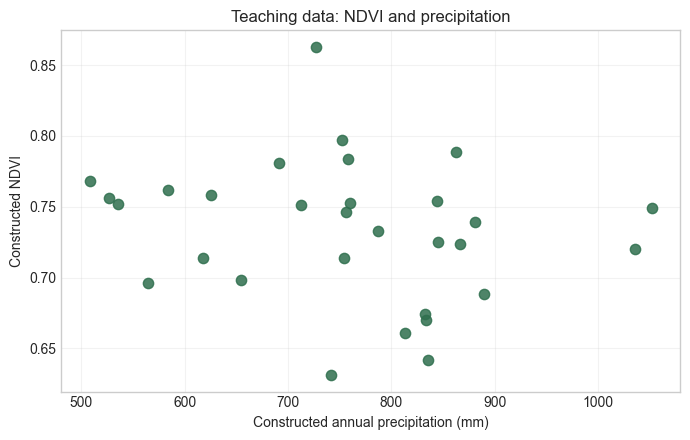

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(data["precip_mm"], data["ndvi"], s=55, color="#2f6f4e", alpha=0.85)
ax.set_xlabel("Constructed annual precipitation (mm)")
ax.set_ylabel("Constructed NDVI")
ax.set_title("Teaching data: NDVI and precipitation")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "precip_ndvi_scatter.png", dpi=200)
plt.show()


## 3. 用 statsmodels 拟合 OLS 并查看 summary

`statsmodels` 的 `OLS` summary 适合教学解释：它同时给出系数、标准误、t 检验、拟合优度和若干诊断信息。这里的回归式为：

`ndvi = intercept + b1 * precip_mm + b2 * temp_c + b3 * elevation_m + error`

注意：这仍然只是构造数据上的统计关联，不是因果识别。


In [4]:
predictors = ["precip_mm", "temp_c", "elevation_m"]
X = data[predictors]
y = data["ndvi"]

X_with_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_with_const)
ols_result = ols_model.fit()
ols_result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   ndvi   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     16.95
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           2.64e-06
Time:                        23:38:24   Log-Likelihood:                 64.336
No. Observations:                  30   AIC:                            -120.7
Df Residuals:                      26   BIC:                            -115.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1752      0.247      0.710      0.484      -0.332       0.682
precip_mm       0.0004   8.41e-05      5.195      0.000       0.000       0.001
temp_c          0.0146      0.009      1.573      0.128      -0.004       0.034
elevation_m -4.409e-05   4.49e-05     -0.982      0.335      -0.000    4.82e-05
==============================================================================
Omnibus:                        0.403   Durbin-Watson:                   2.213
Prob(Omnibus):                  0.817   Jarque-Bera (JB):                0.557
Skew:                           0.163   Prob(JB):                        0.757
Kurtosis:                       2.417   Cond. No.                     7.12e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.12e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 4. 用 sklearn LinearRegression 做预测

`scikit-learn` 的 `LinearRegression` 适合展示模型训练和预测流程。这里把预测值和残差写回表格，用于后续作图。


In [5]:
sk_model = LinearRegression()
sk_model.fit(X, y)

data["predicted_ndvi"] = sk_model.predict(X)
data["residual_ndvi"] = data["ndvi"] - data["predicted_ndvi"]

print(f"Intercept: {sk_model.intercept_:.4f}")
for name, coef in zip(predictors, sk_model.coef_):
    print(f"{name}: {coef:.6f}")
print(f"R^2: {sk_model.score(X, y):.3f}")

data[["site_id", "ndvi", "predicted_ndvi", "residual_ndvi"]].head()


Intercept: 0.1752
precip_mm: 0.000437
temp_c: 0.014594
elevation_m: -0.000044
R^2: 0.662


,site_id,ndvi,predicted_ndvi,residual_ndvi
0,S01,0.863,0.827057,0.035943
1,S02,0.768,0.750697,0.017303
2,S03,0.752,0.746056,0.005944
3,S04,0.756,0.737140,0.018860
4,S05,0.758,0.796284,-0.038284


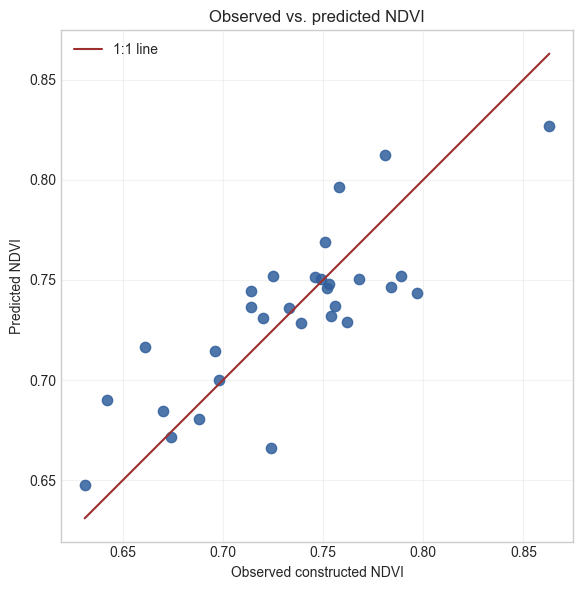

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(data["ndvi"], data["predicted_ndvi"], s=55, color="#315f9c", alpha=0.85)
min_value = min(data["ndvi"].min(), data["predicted_ndvi"].min())
max_value = max(data["ndvi"].max(), data["predicted_ndvi"].max())
ax.plot([min_value, max_value], [min_value, max_value], color="#9c2f2f", linewidth=1.5, label="1:1 line")
ax.set_xlabel("Observed constructed NDVI")
ax.set_ylabel("Predicted NDVI")
ax.set_title("Observed vs. predicted NDVI")
ax.set_aspect("equal", adjustable="box")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "observed_vs_predicted_ndvi.png", dpi=200)
plt.show()


## 5. 标准化回归系数

原始系数受单位影响：降水用 mm，温度用摄氏度，高程用 m，数值大小不能直接比较。把 `X` 和 `y` 标准化后再拟合线性回归，可以得到同一尺度上的系数，用于教学比较相对贡献方向和大小。


In [7]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_standardized = x_scaler.fit_transform(X)
y_standardized = y_scaler.fit_transform(y.to_numpy().reshape(-1, 1)).ravel()

standardized_model = LinearRegression()
standardized_model.fit(X_standardized, y_standardized)

standardized_coefficients = pd.DataFrame({
    "predictor": predictors,
    "standardized_coefficient": standardized_model.coef_,
}).sort_values("standardized_coefficient")

standardized_coefficients


,predictor,standardized_coefficient
2,elevation_m,-0.621388
1,temp_c,0.993612
0,precip_mm,1.207675


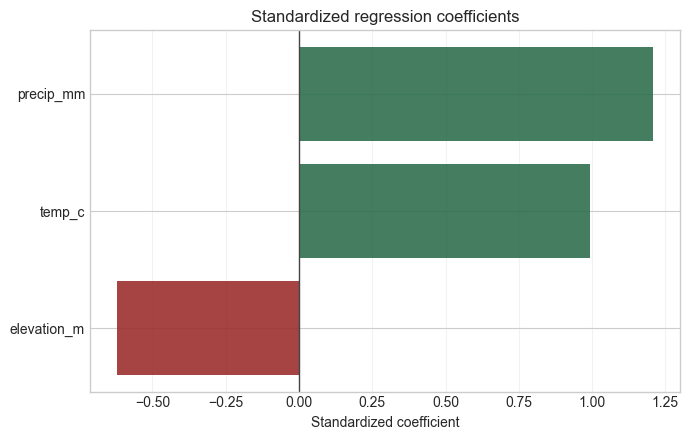

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#9c2f2f" if value < 0 else "#2f6f4e" for value in standardized_coefficients["standardized_coefficient"]]
ax.barh(
    standardized_coefficients["predictor"],
    standardized_coefficients["standardized_coefficient"],
    color=colors,
    alpha=0.9,
)
ax.axvline(0, color="#444444", linewidth=1)
ax.set_xlabel("Standardized coefficient")
ax.set_title("Standardized regression coefficients")
ax.grid(True, axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "standardized_coefficients.png", dpi=200)
plt.show()


## 6. 残差图：预测后还剩什么结构？

残差图把预测值放在横轴、残差放在纵轴。理想情况下，残差应围绕 0 随机分布。若出现明显曲线、漏斗形或分组结构，说明线性模型可能遗漏了变量、非线性关系或尺度问题。


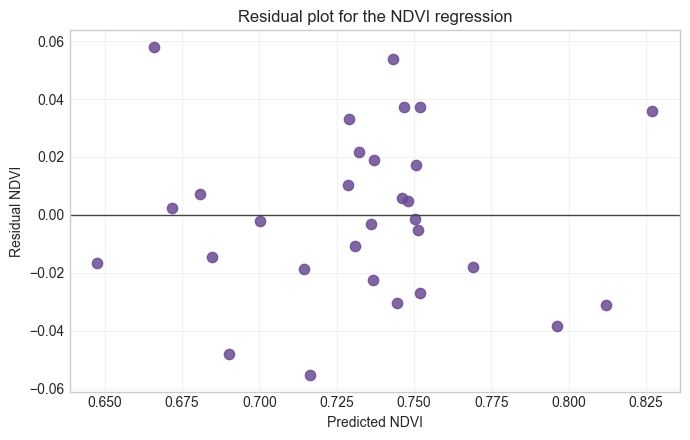

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axhline(0, color="#444444", linewidth=1)
ax.scatter(data["predicted_ndvi"], data["residual_ndvi"], s=55, color="#6a4c93", alpha=0.85)
ax.set_xlabel("Predicted NDVI")
ax.set_ylabel("Residual NDVI")
ax.set_title("Residual plot for the NDVI regression")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "residual_plot.png", dpi=200)
plt.show()


## 7. VIF：解释变量之间是否高度共线？

VIF 衡量一个解释变量能在多大程度上被其他解释变量线性解释。VIF 高并不一定让预测失效，但会让单个系数的解释更不稳定。statsmodels 文档给出的经验提醒是：当 VIF 大于 5 时，该变量与其他解释变量高度共线，参数估计可能有较大的标准误。


In [10]:
vif_table = pd.DataFrame({
    "predictor": predictors,
    "vif": [
        variance_inflation_factor(X_with_const.values, i)
        for i in range(1, X_with_const.shape[1])
    ],
}).sort_values("vif", ascending=False)

vif_table


,predictor,vif
2,elevation_m,30.771444
1,temp_c,30.680054
0,precip_mm,4.152354


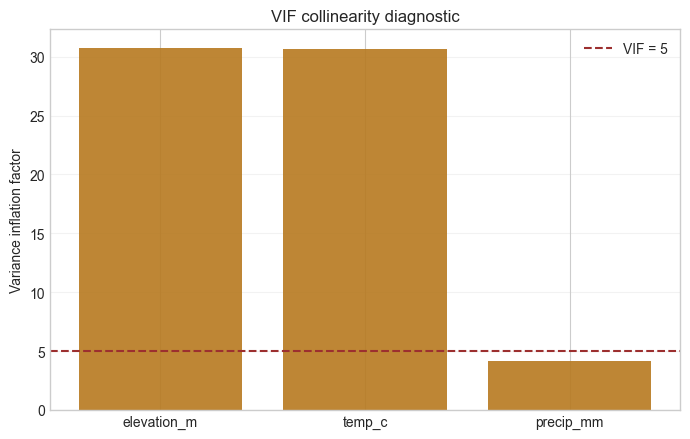

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(vif_table["predictor"], vif_table["vif"], color="#b7791f", alpha=0.9)
ax.axhline(5, color="#9c2f2f", linestyle="--", linewidth=1.5, label="VIF = 5")
ax.set_ylabel("Variance inflation factor")
ax.set_title("VIF collinearity diagnostic")
ax.legend()
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "vif_plot.png", dpi=200)
plt.show()


## 8. 小结

这个构造案例说明，回归分析至少可以回答四类问题：

- **解释关系**：在其他变量同时进入模型时，每个解释变量与 NDVI 的统计关联方向和不确定性是什么？
- **预测结果**：给定降水、温度和高程，模型能给出 NDVI 的线性预测。
- **比较贡献**：标准化系数让不同单位的变量可以在同一尺度上比较。
- **诊断风险**：残差图检查模型遗漏结构，VIF 检查解释变量之间的共线性。

这些结果来自教学构造数据，只能用于理解方法流程。真实研究还需要数据来源说明、抽样设计、误差结构、空间自相关、外部验证和领域机制解释。
